# RQ3 Phase A: Cross-Model Correct Prediction Pool Analysis

This notebook visualises the cross-model agreement pools for RQ3 Phase A sampling.
The analysis determines which source-code samples are correctly predicted by multiple
models, informing the stratified sampling strategy for human evaluation of explanations.

**Dataset**: VulTrial-870 balanced vulnerability dataset (434 vulnerable, 434 safe)  
**Experiments**: 16 SA vulnerability detection experiments (4 models × 4 strata)  
**Models**: Qwen3-4B, Qwen3-30B-A3B, Nemotron-Nano-8B, Nemotron-Super-49B

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Style — matches comprehensive_performance_analysis.ipynb
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

# Directories
PROJECT_DIR = Path('..')
RESULTS_DIR = PROJECT_DIR / 'results'
OUTPUT_DIR = RESULTS_DIR / 'rq3_baseline'
OUTPUT_DIR.mkdir(exist_ok=True)

# Colour palette — model colours by parameter size
MODEL_COLORS = {
    'Qwen3-4B': '#3498db',        # Blue
    'Qwen3-30B-A3B': '#9b59b6',   # Purple
    'Nemotron-Nano-8B': '#00bcd4', # Cyan
    'Nemotron-Super-49B': '#e91e63' # Magenta
}

FAMILY_COLORS = {
    'Qwen': '#8e44ad',
    'Nemotron': '#c0392b'
}

CONSTRAINT_COLORS = {
    '4-of-4': '#e74c3c',
    '3-specific': '#2ecc71',
    '3-of-4-any': '#3498db'
}

MODEL_ORDER = ['Qwen3-4B', 'Qwen3-30B-A3B', 'Nemotron-Nano-8B', 'Nemotron-Super-49B']
STRATA_ORDER = ['think-zero', 'think-few', 'inst-zero', 'inst-few']
STRATA_LABELS = ['Thinking\nZero-shot', 'Thinking\nFew-shot', 'Instruct\nZero-shot', 'Instruct\nFew-shot']

print('Setup complete.')

Setup complete.


## Load Per-Sample Correctness Data

We load per-sample predictions from all 16 SA vulnerability detection experiments
and build a correctness matrix indexed by sample number.

In [2]:
# Load consolidated performance index
cons = pd.read_csv(RESULTS_DIR / 'consolidated_performance.csv')
sa_vuln = cons[(cons['design'] == 'SA') & (cons['task'] == 'vulnerability_detection') & (cons['dataset'] == 'VulTrial-870')].copy()

# Create stratum labels
def make_stratum(row):
    mode = 'think' if row['mode'] == 'thinking' else 'inst'
    prompt = 'zero' if row['prompting'] == 'zero-shot' else 'few'
    return f'{mode}-{prompt}'

sa_vuln['stratum'] = sa_vuln.apply(make_stratum, axis=1)

# Short model names
def short_model(name):
    if '4B' in name and 'Qwen' in name: return 'Qwen3-4B'
    if '30B' in name: return 'Qwen3-30B-A3B'
    if 'Nano' in name: return 'Nemotron-Nano-8B'
    if 'Super' in name: return 'Nemotron-Super-49B'
    return name

sa_vuln['short_model'] = sa_vuln['model'].apply(short_model)

# Load all 16 per-sample CSVs
per_sample = {}
for _, row in sa_vuln.iterrows():
    key = (row['short_model'], row['stratum'])
    ps_path = row['source_file'].replace(
        '_summary_vulnerability_metrics.csv',
        '_per_sample_vulnerability_metrics.csv'
    )
    per_sample[key] = pd.read_csv(ps_path)

print(f'Loaded {len(per_sample)} per-sample files')
for key in sorted(per_sample.keys()):
    df = per_sample[key]
    print(f'  {key[0]:25s} {key[1]:12s}  n={len(df)}')

Loaded 16 per-sample files
  Nemotron-Nano-8B          inst-few      n=486
  Nemotron-Nano-8B          inst-zero     n=486
  Nemotron-Nano-8B          think-few     n=486
  Nemotron-Nano-8B          think-zero    n=486
  Nemotron-Super-49B        inst-few      n=486
  Nemotron-Super-49B        inst-zero     n=486
  Nemotron-Super-49B        think-few     n=484
  Nemotron-Super-49B        think-zero    n=486
  Qwen3-30B-A3B             inst-few      n=486
  Qwen3-30B-A3B             inst-zero     n=486
  Qwen3-30B-A3B             think-few     n=486
  Qwen3-30B-A3B             think-zero    n=486
  Qwen3-4B                  inst-few      n=486
  Qwen3-4B                  inst-zero     n=486
  Qwen3-4B                  think-few     n=486
  Qwen3-4B                  think-zero    n=486


In [3]:
# Build correctness matrix: rows = sample numbers, columns = (model, stratum)
# Derive sample count dynamically from the loaded per-sample data
n_samples = max(df['Sample Number'].max() for df in per_sample.values())
sample_idx = np.arange(1, n_samples + 1)
correct_matrix = pd.DataFrame(index=sample_idx)
correct_matrix.index.name = 'Sample Number'

# Ground truth (consistent across experiments) — collect from ALL experiments
# to fill gaps where individual configs may have fewer samples (e.g., 484 vs 486)
gt_series = pd.Series(dtype=float, index=sample_idx)

for (model, stratum), df in per_sample.items():
    col = f'{model}__{stratum}'
    df_idx = df.set_index('Sample Number')
    correct_matrix[col] = df_idx['Is Correct'].reindex(sample_idx).fillna(False).astype(bool)
    # Fill ground truth from any experiment that has this sample
    gt_update = df_idx['Ground Truth'].reindex(sample_idx)
    gt_series = gt_series.fillna(gt_update)

gt = gt_series.fillna(-1).astype(int)  # -1 for any remaining gaps (should be none)
n_vuln = int((gt == 1).sum())
n_safe = int((gt == 0).sum())
print(f'Correctness matrix: {correct_matrix.shape[0]} samples x {correct_matrix.shape[1]} experiments')
print(f'Ground truth: {n_vuln} vulnerable, {n_safe} safe')
if (gt == -1).any():
    print(f'WARNING: {(gt == -1).sum()} samples with missing ground truth')

Correctness matrix: 486 samples x 16 experiments
Ground truth: 243 vulnerable, 243 safe


## 1. Per-Experiment Accuracy Heatmap (D9b)

Baseline accuracy for each of the 16 individual experiments — no cross-model constraint.
Each cell shows total correct predictions with TP/TN breakdown.
Colour scale centres at 50% of the dataset size.

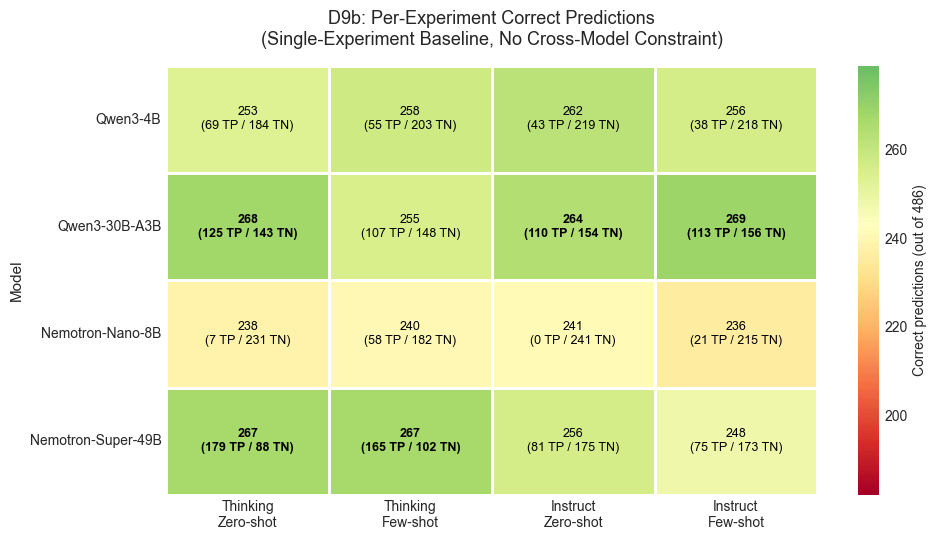

Saved: ../results/rq3_baseline/rq3_pool_d9b_heatmap.png


In [4]:
# Compute D9b: per-model per-stratum correctness counts
# Use each experiment's own per_sample data (avoids GT alignment issues
# for experiments which may have fewer samples due to context overflow skips)
d9b_total = np.zeros((4, 4))
d9b_tp = np.zeros((4, 4))
d9b_tn = np.zeros((4, 4))

for i, model in enumerate(MODEL_ORDER):
    for j, stratum in enumerate(STRATA_ORDER):
        df = per_sample[(model, stratum)]
        correct = df['Is Correct'] == True
        d9b_total[i, j] = correct.sum()
        d9b_tp[i, j] = (correct & (df['Ground Truth'] == 1)).sum()
        d9b_tn[i, j] = (correct & (df['Ground Truth'] == 0)).sum()

# Heatmap — dynamic scale based on dataset size
half_n = n_samples // 2
vmin_d9b = int(half_n * 0.75)
vmax_d9b = int(half_n * 1.15)

fig, ax = plt.subplots(figsize=(10, 5.5))

sns.heatmap(
    d9b_total, annot=False, cmap='RdYlGn', center=half_n,
    xticklabels=['Thinking\nZero-shot', 'Thinking\nFew-shot',
                 'Instruct\nZero-shot', 'Instruct\nFew-shot'],
    yticklabels=MODEL_ORDER,
    ax=ax, linewidths=2, linecolor='white',
    vmin=vmin_d9b, vmax=vmax_d9b,
    cbar_kws={'label': f'Correct predictions (out of {n_samples})'}
)

# Custom annotations with TP/TN breakdown
for i in range(4):
    for j in range(4):
        total = int(d9b_total[i, j])
        tp = int(d9b_tp[i, j])
        tn = int(d9b_tn[i, j])
        ax.text(j + 0.5, i + 0.5,
                f'{total}\n({tp} TP / {tn} TN)',
                ha='center', va='center', fontsize=9,
                fontweight='bold' if total >= half_n * 1.08 else 'normal',
                color='black')

ax.set_title('D9b: Per-Experiment Correct Predictions\n(Single-Experiment Baseline, No Cross-Model Constraint)',
             fontsize=13, pad=15)
ax.set_ylabel('Model', fontsize=11)
ax.set_xlabel('')
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq3_pool_d9b_heatmap.png', bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR / "rq3_pool_d9b_heatmap.png"}')

## 2. Pool Sizes by Constraint Level (D2 vs D5b vs D5)

Compares three cross-model agreement strategies per stratum:
- **4-of-4 (D2)**: All 4 models must agree — strictest
- **3 specific (D5b)**: Qwen3-4B + Qwen3-30B-A3B + Nemotron-Super-49B — excludes the bottleneck
- **≥3-of-4 any (D5)**: Any 3 of 4 models — most relaxed

In [5]:
# Compute pool sizes for each constraint level
d2_pool, d2_tp, d2_tn = {}, {}, {}
d5b_pool, d5b_tp, d5b_tn = {}, {}, {}
d5_pool, d5_tp, d5_tn = {}, {}, {}

models_3spec = [m for m in MODEL_ORDER if m != 'Nemotron-Nano-8B']

for stratum in STRATA_ORDER:
    cols_all = [f'{m}__{stratum}' for m in MODEL_ORDER]
    cols_3spec = [f'{m}__{stratum}' for m in models_3spec]

    # D2: All 4 correct
    mask = correct_matrix[cols_all].all(axis=1)
    d2_pool[stratum] = int(mask.sum())
    d2_tp[stratum] = int((mask & (gt == 1)).sum())
    d2_tn[stratum] = int((mask & (gt == 0)).sum())

    # D5b: 3 specific correct
    mask = correct_matrix[cols_3spec].all(axis=1)
    d5b_pool[stratum] = int(mask.sum())
    d5b_tp[stratum] = int((mask & (gt == 1)).sum())
    d5b_tn[stratum] = int((mask & (gt == 0)).sum())

    # D5: >= 3 of 4 any
    n_correct = correct_matrix[cols_all].sum(axis=1)
    mask = n_correct >= 3
    d5_pool[stratum] = int(mask.sum())
    d5_tp[stratum] = int((mask & (gt == 1)).sum())
    d5_tn[stratum] = int((mask & (gt == 0)).sum())

# Print verification
print(f'{"Stratum":<15} {"D2 (4/4)":>12} {"D5b (3 spec)":>14} {"D5 (>=3/4)":>14}')
print('-' * 58)
for s in STRATA_ORDER:
    print(f'{s:<15} {d2_pool[s]:>4} ({d2_tp[s]:>2} TP) '
          f'{d5b_pool[s]:>6} ({d5b_tp[s]:>2} TP) '
          f'{d5_pool[s]:>6} ({d5_tp[s]:>2} TP)')

Stratum             D2 (4/4)   D5b (3 spec)     D5 (>=3/4)
----------------------------------------------------------
think-zero        58 ( 2 TP)    105 (46 TP)    191 (49 TP)
think-few         59 ( 9 TP)    102 (35 TP)    183 (49 TP)
inst-zero        117 ( 0 TP)    138 (20 TP)    215 (20 TP)
inst-few         103 ( 2 TP)    131 (16 TP)    206 (18 TP)


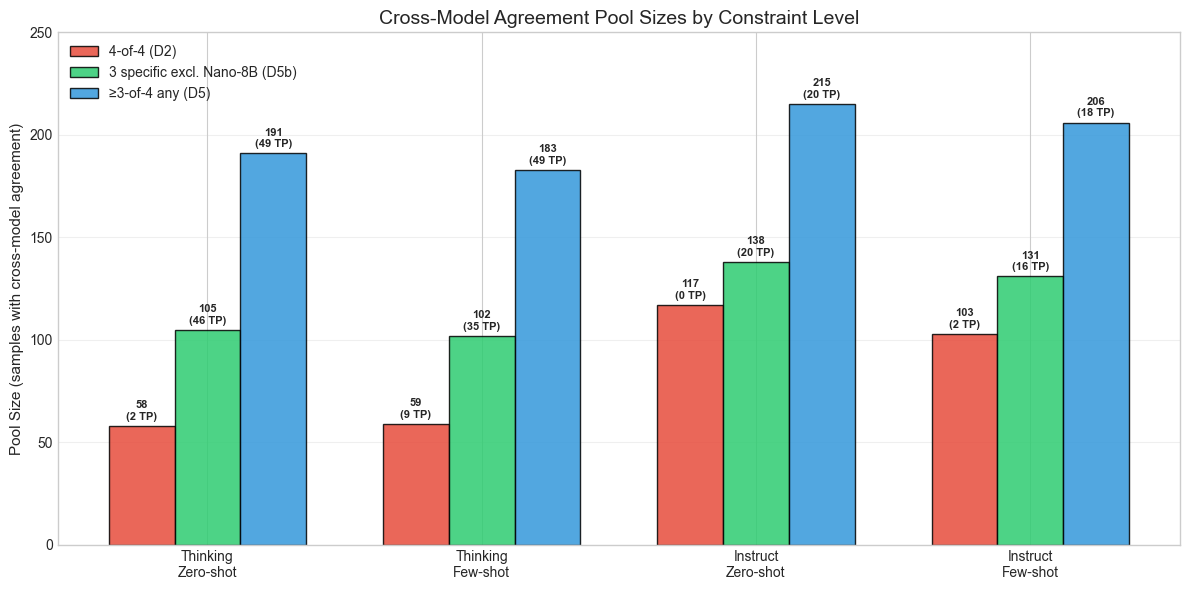

Saved: ../results/rq3_baseline/rq3_pool_constraint_comparison.png


In [6]:
# Grouped bar chart
x = np.arange(len(STRATA_ORDER))
width = 0.24

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, [d2_pool[s] for s in STRATA_ORDER], width,
               label='4-of-4 (D2)', color=CONSTRAINT_COLORS['4-of-4'],
               edgecolor='black', linewidth=1, alpha=0.85)
bars2 = ax.bar(x, [d5b_pool[s] for s in STRATA_ORDER], width,
               label='3 specific excl. Nano-8B (D5b)', color=CONSTRAINT_COLORS['3-specific'],
               edgecolor='black', linewidth=1, alpha=0.85)
bars3 = ax.bar(x + width, [d5_pool[s] for s in STRATA_ORDER], width,
               label='\u22653-of-4 any (D5)', color=CONSTRAINT_COLORS['3-of-4-any'],
               edgecolor='black', linewidth=1, alpha=0.85)

# Annotate bars with pool size and TP count
for bars, pool_d, tp_d in [(bars1, d2_pool, d2_tp),
                            (bars2, d5b_pool, d5b_tp),
                            (bars3, d5_pool, d5_tp)]:
    for bar, s in zip(bars, STRATA_ORDER):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., h + 2,
                f'{int(h)}\n({int(tp_d[s])} TP)',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(STRATA_LABELS, fontsize=10)
ax.set_ylabel('Pool Size (samples with cross-model agreement)', fontsize=11)
ax.set_title('Cross-Model Agreement Pool Sizes by Constraint Level', fontsize=14)
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 250)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq3_pool_constraint_comparison.png', bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR / "rq3_pool_constraint_comparison.png"}')

## 3. TP/TN Composition — D5b per Stratum

Shows the TP/TN balance within the preferred 3-specific-model constraint (D5b).
The imbalance highlights the SA design's inherent TN bias, amplified by cross-model intersection.

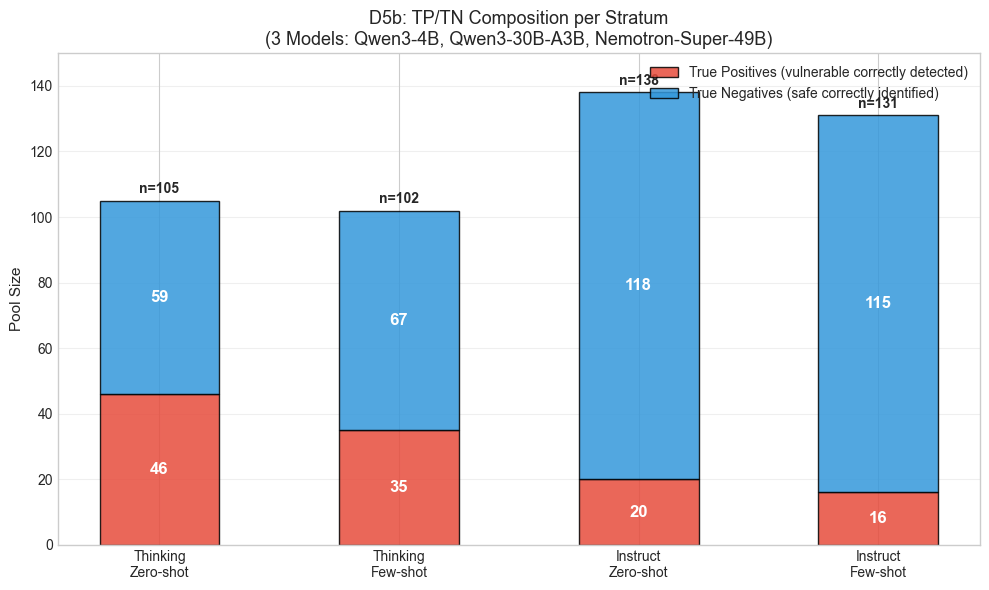

Saved: ../results/rq3_baseline/rq3_pool_d5b_tp_tn_composition.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(STRATA_ORDER))
width = 0.5

tp_vals = [d5b_tp[s] for s in STRATA_ORDER]
tn_vals = [d5b_tn[s] for s in STRATA_ORDER]

bars_tp = ax.bar(x, tp_vals, width,
                 label='True Positives (vulnerable correctly detected)',
                 color='#e74c3c', edgecolor='black', linewidth=1, alpha=0.85)
bars_tn = ax.bar(x, tn_vals, width, bottom=tp_vals,
                 label='True Negatives (safe correctly identified)',
                 color='#3498db', edgecolor='black', linewidth=1, alpha=0.85)

# Annotations inside bars
for i in range(len(STRATA_ORDER)):
    tp, tn = tp_vals[i], tn_vals[i]
    total = tp + tn
    # TP label (inside red bar)
    if tp > 5:
        ax.text(i, tp / 2, f'{tp}', ha='center', va='center',
                fontsize=12, fontweight='bold', color='white')
    # TN label (inside blue bar)
    ax.text(i, tp + tn / 2, f'{tn}', ha='center', va='center',
            fontsize=12, fontweight='bold', color='white')
    # Total above bar
    ax.text(i, total + 1.5, f'n={total}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(STRATA_LABELS, fontsize=10)
ax.set_ylabel('Pool Size', fontsize=11)
ax.set_title('D5b: TP/TN Composition per Stratum\n'
             '(3 Models: Qwen3-4B, Qwen3-30B-A3B, Nemotron-Super-49B)',
             fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 150)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq3_pool_d5b_tp_tn_composition.png', bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR / "rq3_pool_d5b_tp_tn_composition.png"}')

## 3b. D5b by Prompting Style (Zero-shot vs Few-shot)

Compares the 3-model (D5b) pools grouped by prompting style. Each group shows
the two mode strata plus the stricter "both modes" constraint (correct in both
thinking and instruct for that prompting style).

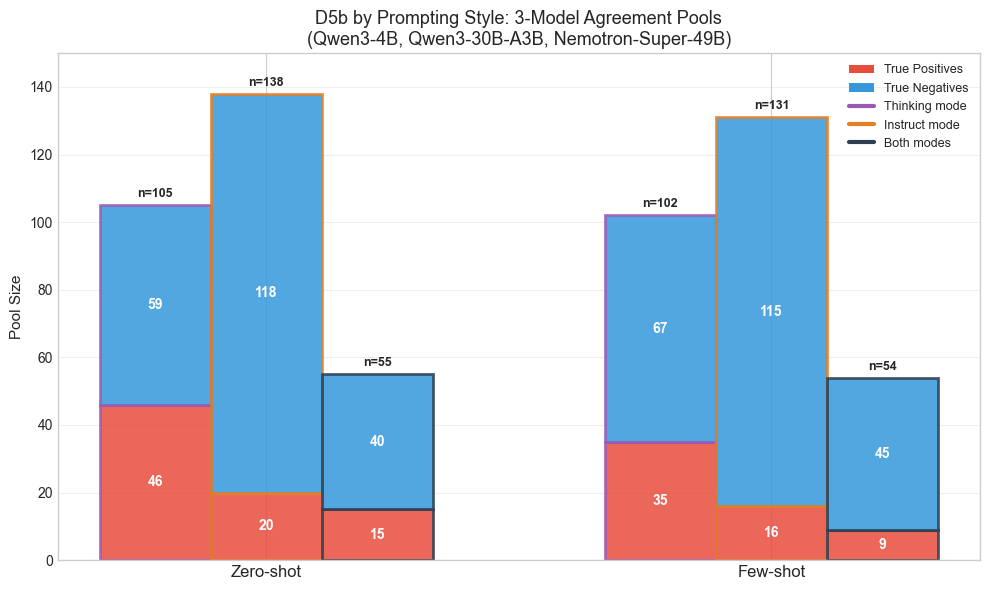

Saved: ../results/rq3_baseline/rq3_pool_d5b_by_prompting.png


In [8]:
# D5b per prompting: all 3 models correct in both modes for a given prompting style
models_3spec = [m for m in MODEL_ORDER if m != 'Nemotron-Nano-8B']

d5b_prompt = {}
for prompt_label, strata_pair in [('zero-shot', ['think-zero', 'inst-zero']),
                                   ('few-shot', ['think-few', 'inst-few'])]:
    cols = [f'{m}__{s}' for m in models_3spec for s in strata_pair]
    mask = correct_matrix[cols].all(axis=1)
    d5b_prompt[prompt_label] = {
        'pool': int(mask.sum()),
        'tp': int((mask & (gt == 1)).sum()),
        'tn': int((mask & (gt == 0)).sum()),
    }

# Build chart data: for each prompting style show Thinking, Instruct, Both Modes
groups = ['Zero-shot', 'Few-shot']
bar_labels = ['Thinking mode', 'Instruct mode', 'Both modes']
strata_map = {
    'Zero-shot': ('think-zero', 'inst-zero', 'zero-shot'),
    'Few-shot': ('think-few', 'inst-few', 'few-shot'),
}

tp_data = []
tn_data = []
for grp in groups:
    s_think, s_inst, s_both = strata_map[grp]
    tp_data.append([d5b_tp[s_think], d5b_tp[s_inst], d5b_prompt[s_both.replace('-shot', '-shot')]['tp']])
    tn_data.append([d5b_tn[s_think], d5b_tn[s_inst], d5b_prompt[s_both]['tn']])

# Grouped stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))

n_groups = len(groups)
n_bars = len(bar_labels)
width = 0.22
bar_colors = ['#9b59b6', '#e67e22', '#2c3e50']  # Purple, Orange, Dark

for b in range(n_bars):
    tp_vals = [tp_data[g][b] for g in range(n_groups)]
    tn_vals = [tn_data[g][b] for g in range(n_groups)]
    x = np.arange(n_groups) + (b - 1) * width

    ax.bar(x, tp_vals, width, color='#e74c3c', edgecolor=bar_colors[b],
           linewidth=2, alpha=0.85)
    ax.bar(x, tn_vals, width, bottom=tp_vals, color='#3498db',
           edgecolor=bar_colors[b], linewidth=2, alpha=0.85)

    # Annotations
    for g in range(n_groups):
        tp, tn = tp_vals[g], tn_vals[g]
        total = tp + tn
        if tp > 3:
            ax.text(x[g], tp / 2, f'{tp}', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white')
        ax.text(x[g], tp + tn / 2, f'{tn}', ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')
        ax.text(x[g], total + 1.5, f'n={total}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

ax.set_xticks(np.arange(n_groups))
ax.set_xticklabels(groups, fontsize=12)
ax.set_ylabel('Pool Size', fontsize=11)
ax.set_title('D5b by Prompting Style: 3-Model Agreement Pools\n'
             '(Qwen3-4B, Qwen3-30B-A3B, Nemotron-Super-49B)',
             fontsize=13)

# Custom legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor='#e74c3c', label='True Positives'),
    Patch(facecolor='#3498db', label='True Negatives'),
    Line2D([0], [0], color='#9b59b6', lw=3, label='Thinking mode'),
    Line2D([0], [0], color='#e67e22', lw=3, label='Instruct mode'),
    Line2D([0], [0], color='#2c3e50', lw=3, label='Both modes'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 150)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq3_pool_d5b_by_prompting.png', bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR / "rq3_pool_d5b_by_prompting.png"}')

## 4. Cross-Model Family Agreement Heatmap (D8b)

Agreement within model families — Qwen (4B + 30B) vs Nemotron (8B + 49B).
Highlights how the Nemotron family is constrained by Nano-8B's weak vulnerability detection.

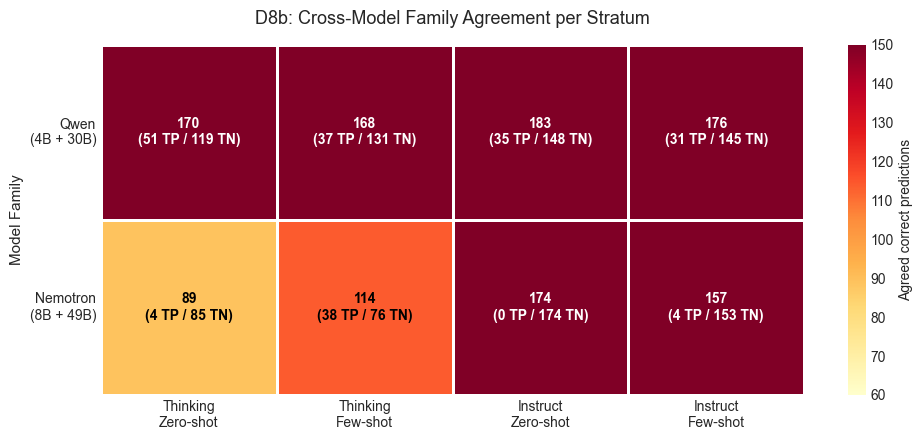

Saved: ../results/rq3_baseline/rq3_pool_d8b_family_heatmap.png


In [9]:
# Compute D8b: per-family per-stratum agreement
families = {
    'Qwen': ['Qwen3-4B', 'Qwen3-30B-A3B'],
    'Nemotron': ['Nemotron-Nano-8B', 'Nemotron-Super-49B']
}
family_order = ['Qwen', 'Nemotron']

d8b_pool = np.zeros((2, 4))
d8b_tp = np.zeros((2, 4))
d8b_tn = np.zeros((2, 4))

for i, family in enumerate(family_order):
    for j, stratum in enumerate(STRATA_ORDER):
        cols = [f'{m}__{stratum}' for m in families[family]]
        mask = correct_matrix[cols].all(axis=1)
        d8b_pool[i, j] = mask.sum()
        d8b_tp[i, j] = (mask & (gt == 1)).sum()
        d8b_tn[i, j] = (mask & (gt == 0)).sum()

# Heatmap
fig, ax = plt.subplots(figsize=(10, 4.5))

sns.heatmap(
    d8b_pool, annot=False, cmap='YlOrRd',
    xticklabels=['Thinking\nZero-shot', 'Thinking\nFew-shot',
                 'Instruct\nZero-shot', 'Instruct\nFew-shot'],
    yticklabels=['Qwen\n(4B + 30B)', 'Nemotron\n(8B + 49B)'],
    ax=ax, linewidths=2, linecolor='white',
    vmin=60, vmax=150,
    cbar_kws={'label': 'Agreed correct predictions'}
)

# Custom annotations
for i in range(2):
    for j in range(4):
        total = int(d8b_pool[i, j])
        tp = int(d8b_tp[i, j])
        tn = int(d8b_tn[i, j])
        text_color = 'white' if total >= 130 else 'black'
        ax.text(j + 0.5, i + 0.5,
                f'{total}\n({tp} TP / {tn} TN)',
                ha='center', va='center', fontsize=10,
                fontweight='bold', color=text_color)

ax.set_title('D8b: Cross-Model Family Agreement per Stratum', fontsize=13, pad=15)
ax.set_ylabel('Model Family', fontsize=11)
ax.set_xlabel('')
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq3_pool_d8b_family_heatmap.png', bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR / "rq3_pool_d8b_family_heatmap.png"}')

## 5. Summary Comparison Table

Side-by-side view of the three constraint strategies with pool sizes and TP counts.
D5b (3 specific models, excluding Nemotron-Nano-8B) is the recommended approach.

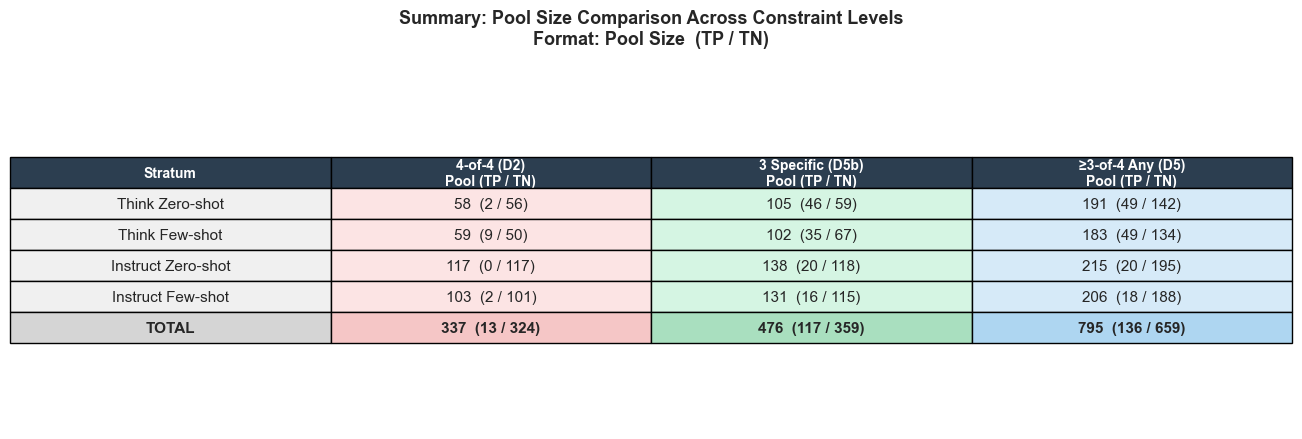

Saved: ../results/rq3_baseline/rq3_pool_summary_table.png


In [10]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.axis('off')

columns = ['Stratum',
           '4-of-4 (D2)\nPool (TP / TN)',
           '3 Specific (D5b)\nPool (TP / TN)',
           '\u22653-of-4 Any (D5)\nPool (TP / TN)']

strata_names = ['Think Zero-shot', 'Think Few-shot',
                'Instruct Zero-shot', 'Instruct Few-shot']

cell_data = []
cell_colors = []

for s, label in zip(STRATA_ORDER, strata_names):
    row = [
        label,
        f"{d2_pool[s]}  ({d2_tp[s]} / {d2_tn[s]})",
        f"{d5b_pool[s]}  ({d5b_tp[s]} / {d5b_tn[s]})",
        f"{d5_pool[s]}  ({d5_tp[s]} / {d5_tn[s]})",
    ]
    cell_data.append(row)
    cell_colors.append(['#f0f0f0', '#fce4e4', '#d5f5e3', '#d6eaf8'])

# Add totals row
d2_total = sum(d2_pool[s] for s in STRATA_ORDER)
d2_tp_total = sum(d2_tp[s] for s in STRATA_ORDER)
d2_tn_total = sum(d2_tn[s] for s in STRATA_ORDER)
d5b_total = sum(d5b_pool[s] for s in STRATA_ORDER)
d5b_tp_total = sum(d5b_tp[s] for s in STRATA_ORDER)
d5b_tn_total = sum(d5b_tn[s] for s in STRATA_ORDER)
d5_total = sum(d5_pool[s] for s in STRATA_ORDER)
d5_tp_total = sum(d5_tp[s] for s in STRATA_ORDER)
d5_tn_total = sum(d5_tn[s] for s in STRATA_ORDER)

cell_data.append([
    'TOTAL',
    f"{d2_total}  ({d2_tp_total} / {d2_tn_total})",
    f"{d5b_total}  ({d5b_tp_total} / {d5b_tn_total})",
    f"{d5_total}  ({d5_tp_total} / {d5_tn_total})",
])
cell_colors.append(['#d5d5d5', '#f5c6c6', '#a9dfbf', '#aed6f1'])

table = ax.table(
    cellText=cell_data, colLabels=columns,
    cellColours=cell_colors, loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Style header row
for j in range(len(columns)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold', fontsize=10)

# Bold the totals row
for j in range(len(columns)):
    table[len(cell_data), j].set_text_props(fontweight='bold')

ax.set_title('Summary: Pool Size Comparison Across Constraint Levels\n'
             'Format: Pool Size  (TP / TN)',
             fontsize=13, pad=20, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq3_pool_summary_table.png', bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR / "rq3_pool_summary_table.png"}')

## Key Observations

1. **Nemotron-Nano-8B is the systematic bottleneck**: Near-chance accuracy across strata.
   Including it in any cross-model constraint eliminates nearly all TP.

2. **D5b (3 specific models) is the practical sweet spot**: Excluding Nemotron-Nano-8B recovers TP
   diversity with pool sizes sufficient for stratified sampling.

3. **Thinking mode produces more TP agreement** than instruct mode across all constraint levels,
   likely because extended reasoning helps models converge on correct vulnerability identification.

4. **SA design has inherent TN bias**: The cross-model intersection amplifies this bias because models
   are more likely to agree on easy TN cases than on correctly identifying vulnerable code.

## 6. Best-Model Analysis: Nemotron-Super-49B Only

RQ1 identified Nemotron-Super-49B as the best-performing model for vulnerability detection
(SA thinking zero-shot F1 = 0.627). Cross-model agreement constraints severely limit pool
sizes (especially TP counts). An alternative approach: **use only the best model's correct
predictions** per stratum, removing the cross-model bottleneck entirely.

This section analyses whether Nemotron-Super-49B's individual per-stratum pools are
sufficient for stratified sampling (≥97 per stratum for 95% CI, 5% margin at n=385).

In [11]:
# Build Super-49B sub-matrix
super49_strata = [f'Nemotron-Super-49B__{s}' for s in STRATA_ORDER]
super49_matrix = correct_matrix[super49_strata].copy()
super49_matrix.columns = STRATA_ORDER

# Per-stratum statistics
s49_stats = {}
for s in STRATA_ORDER:
    mask = super49_matrix[s]
    total = int(mask.sum())
    tp = int((mask & (gt == 1)).sum())
    tn = int((mask & (gt == 0)).sum())
    s49_stats[s] = {'pool': total, 'tp': tp, 'tn': tn}

# Cross-stratum intersections
s49_cross = {}
combos = [
    ('All 4 strata', STRATA_ORDER),
    ('Thinking only\n(zero + few)', ['think-zero', 'think-few']),
    ('Instruct only\n(zero + few)', ['inst-zero', 'inst-few']),
    ('Zero-shot only\n(think + inst)', ['think-zero', 'inst-zero']),
    ('Few-shot only\n(think + inst)', ['think-few', 'inst-few']),
    ('Think-zero +\nInst-few', ['think-zero', 'inst-few']),
    ('Think-few +\nInst-zero', ['think-few', 'inst-zero']),
]

for label, strata in combos:
    mask = super49_matrix[strata].all(axis=1)
    total = int(mask.sum())
    tp = int((mask & (gt == 1)).sum())
    tn = int((mask & (gt == 0)).sum())
    s49_cross[label] = {'pool': total, 'tp': tp, 'tn': tn}

# Union: correct in at least one stratum
any_correct = super49_matrix.any(axis=1)
s49_union = {
    'pool': int(any_correct.sum()),
    'tp': int((any_correct & (gt == 1)).sum()),
    'tn': int((any_correct & (gt == 0)).sum()),
}

# Statistical threshold
N_MIN = int(np.ceil((1.96**2 * 0.5 * 0.5) / 0.05**2))  # 385
N_PER_STRATUM = int(np.ceil(N_MIN / 4))  # 97

print('Nemotron-Super-49B: Per-Stratum Pools')
print(f'{"Stratum":<15} {"Pool":>6} {"TP":>6} {"TN":>6} {"TP%":>7} {"Sufficient":>10}')
print('-' * 55)
for s in STRATA_ORDER:
    d = s49_stats[s]
    tp_pct = d['tp'] / d['pool'] * 100
    ok = 'YES' if d['pool'] >= N_PER_STRATUM else 'NO'
    print(f"{s:<15} {d['pool']:>6} {d['tp']:>6} {d['tn']:>6} {tp_pct:>6.1f}% {ok:>10}")

print(f'\nMinimum per stratum for 95% CI / 5% margin: {N_PER_STRATUM}')
print(f'Union (correct in >= 1 stratum): {s49_union["pool"]} (TP={s49_union["tp"]}, TN={s49_union["tn"]})')

Nemotron-Super-49B: Per-Stratum Pools
Stratum           Pool     TP     TN     TP% Sufficient
-------------------------------------------------------
think-zero         267    179     88   67.0%        YES
think-few          267    165    102   61.8%        YES
inst-zero          256     81    175   31.6%        YES
inst-few           248     75    173   30.2%        YES

Minimum per stratum for 95% CI / 5% margin: 97
Union (correct in >= 1 stratum): 432 (TP=209, TN=223)


### 6a. Per-Stratum Pool Heatmap — Super-49B Only

Single-row heatmap showing correct predictions per stratum with TP/TN breakdown.
Compare directly against the D9b row for Nemotron-Super-49B (Section 1).

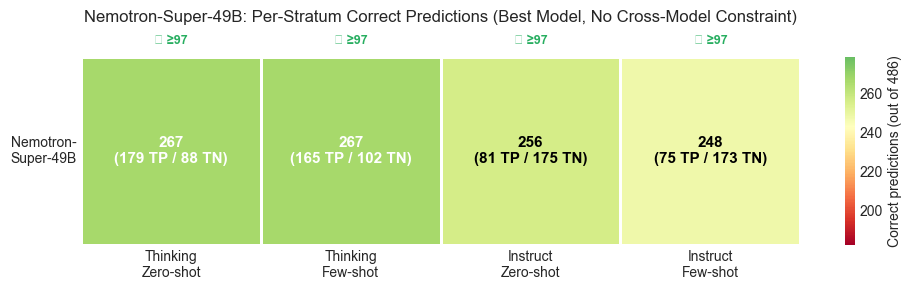

Saved: ../results/rq3_baseline/rq3_pool_super49b_heatmap.png


In [12]:
# 6a. Per-stratum heatmap for Super-49B
fig, ax = plt.subplots(figsize=(10, 3))

pool_data = np.array([[s49_stats[s]['pool'] for s in STRATA_ORDER]])

sns.heatmap(
    pool_data, annot=False, cmap='RdYlGn',
    xticklabels=STRATA_LABELS,
    yticklabels=['Nemotron-\nSuper-49B'],
    ax=ax, linewidths=2, linecolor='white',
    vmin=vmin_d9b, vmax=vmax_d9b, center=half_n,
    cbar_kws={'label': f'Correct predictions (out of {n_samples})'}
)

# Custom annotations
for j, s in enumerate(STRATA_ORDER):
    d = s49_stats[s]
    color = 'white' if d['pool'] >= half_n * 1.08 else 'black'
    ax.text(j + 0.5, 0.5,
            f"{d['pool']}\n({d['tp']} TP / {d['tn']} TN)",
            ha='center', va='center', fontsize=11,
            fontweight='bold', color=color)

# Sufficiency markers
for j, s in enumerate(STRATA_ORDER):
    sufficient = s49_stats[s]['pool'] >= N_PER_STRATUM
    marker = '\u2714' if sufficient else '\u2718'
    color = '#27ae60' if sufficient else '#e74c3c'
    ax.text(j + 0.5, 1.05, f'{marker} \u2265{N_PER_STRATUM}',
            ha='center', va='bottom', fontsize=9, color=color,
            fontweight='bold', transform=ax.get_xaxis_transform())

ax.set_title('Nemotron-Super-49B: Per-Stratum Correct Predictions (Best Model, No Cross-Model Constraint)',
             fontsize=12, pad=25)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq3_pool_super49b_heatmap.png', bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR / "rq3_pool_super49b_heatmap.png"}')

### 6b. TP/TN Composition per Stratum — Super-49B Only

Stacked bars showing the TP/TN balance within each stratum. Thinking mode is TP-heavy
(65% TP), while instruct mode is TN-heavy (28–32% TP) — relevant for balanced sampling.

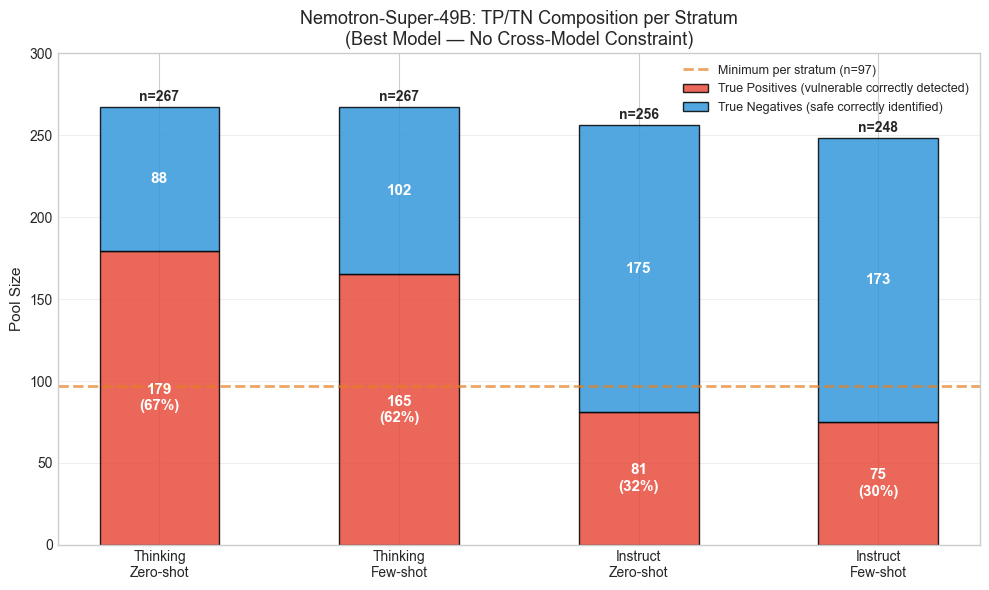

Saved: ../results/rq3_baseline/rq3_pool_super49b_tp_tn.png


In [13]:
# 6b. TP/TN composition stacked bars — Super-49B
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(STRATA_ORDER))
width = 0.5

tp_vals = [s49_stats[s]['tp'] for s in STRATA_ORDER]
tn_vals = [s49_stats[s]['tn'] for s in STRATA_ORDER]

bars_tp = ax.bar(x, tp_vals, width,
                 label='True Positives (vulnerable correctly detected)',
                 color='#e74c3c', edgecolor='black', linewidth=1, alpha=0.85)
bars_tn = ax.bar(x, tn_vals, width, bottom=tp_vals,
                 label='True Negatives (safe correctly identified)',
                 color='#3498db', edgecolor='black', linewidth=1, alpha=0.85)

for i, s in enumerate(STRATA_ORDER):
    tp, tn = tp_vals[i], tn_vals[i]
    total = tp + tn
    tp_pct = tp / total * 100
    # TP inside red bar
    ax.text(i, tp / 2, f'{tp}\n({tp_pct:.0f}%)', ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')
    # TN inside blue bar
    ax.text(i, tp + tn / 2, f'{tn}', ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')
    # Total above bar
    ax.text(i, total + 2, f'n={total}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

# Sufficiency line
ax.axhline(y=N_PER_STRATUM, color='#e67e22', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Minimum per stratum (n={N_PER_STRATUM})')

ax.set_xticks(x)
ax.set_xticklabels(STRATA_LABELS, fontsize=10)
ax.set_ylabel('Pool Size', fontsize=11)
ax.set_title('Nemotron-Super-49B: TP/TN Composition per Stratum\n'
             '(Best Model — No Cross-Model Constraint)',
             fontsize=13)
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 300)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq3_pool_super49b_tp_tn.png', bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR / "rq3_pool_super49b_tp_tn.png"}')

### 6c. Cross-Stratum Intersection Pools — Super-49B Only

When the same code sample must be correctly predicted across multiple strata (e.g.,
both thinking and instruct modes), the pool shrinks. This chart shows viable pairwise
and higher-order intersections for within-sample cross-stratum explanation comparison.

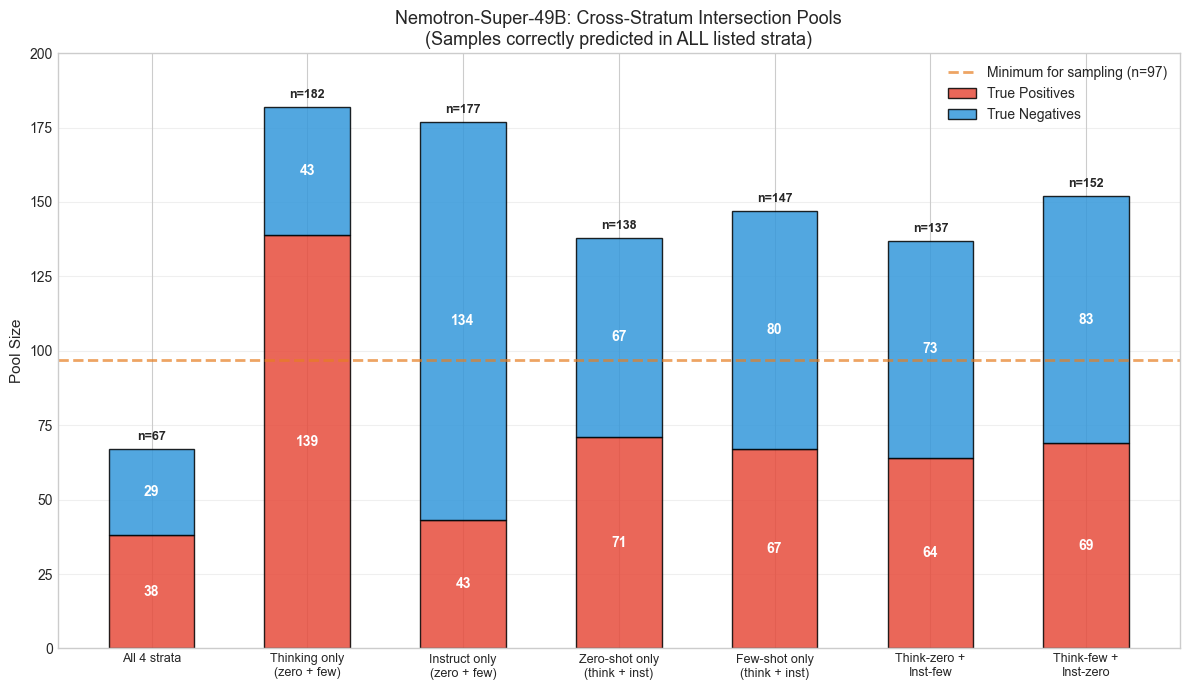

Saved: ../results/rq3_baseline/rq3_pool_super49b_intersections.png


In [14]:
# 6c. Cross-stratum intersection bar chart — Super-49B
fig, ax = plt.subplots(figsize=(12, 7))

labels = list(s49_cross.keys())
pools = [s49_cross[k]['pool'] for k in labels]
tps = [s49_cross[k]['tp'] for k in labels]
tns = [s49_cross[k]['tn'] for k in labels]

x = np.arange(len(labels))
width = 0.55

bars_tp = ax.bar(x, tps, width, label='True Positives',
                 color='#e74c3c', edgecolor='black', linewidth=1, alpha=0.85)
bars_tn = ax.bar(x, tns, width, bottom=tps, label='True Negatives',
                 color='#3498db', edgecolor='black', linewidth=1, alpha=0.85)

for i in range(len(labels)):
    tp, tn = tps[i], tns[i]
    total = tp + tn
    if tp > 5:
        ax.text(i, tp / 2, f'{tp}', ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')
    ax.text(i, tp + tn / 2, f'{tn}', ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')
    ax.text(i, total + 2, f'n={total}', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

# Sufficiency line
ax.axhline(y=N_PER_STRATUM, color='#e67e22', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Minimum for sampling (n={N_PER_STRATUM})')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9, ha='center')
ax.set_ylabel('Pool Size', fontsize=11)
ax.set_title('Nemotron-Super-49B: Cross-Stratum Intersection Pools\n'
             '(Samples correctly predicted in ALL listed strata)',
             fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 200)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq3_pool_super49b_intersections.png', bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR / "rq3_pool_super49b_intersections.png"}')

### 6d. Summary Table — Super-49B vs Cross-Model Approaches

Side-by-side comparison of the best-model (Super-49B only) per-stratum pools
against the previous cross-model constraints (D2, D5b, D5).

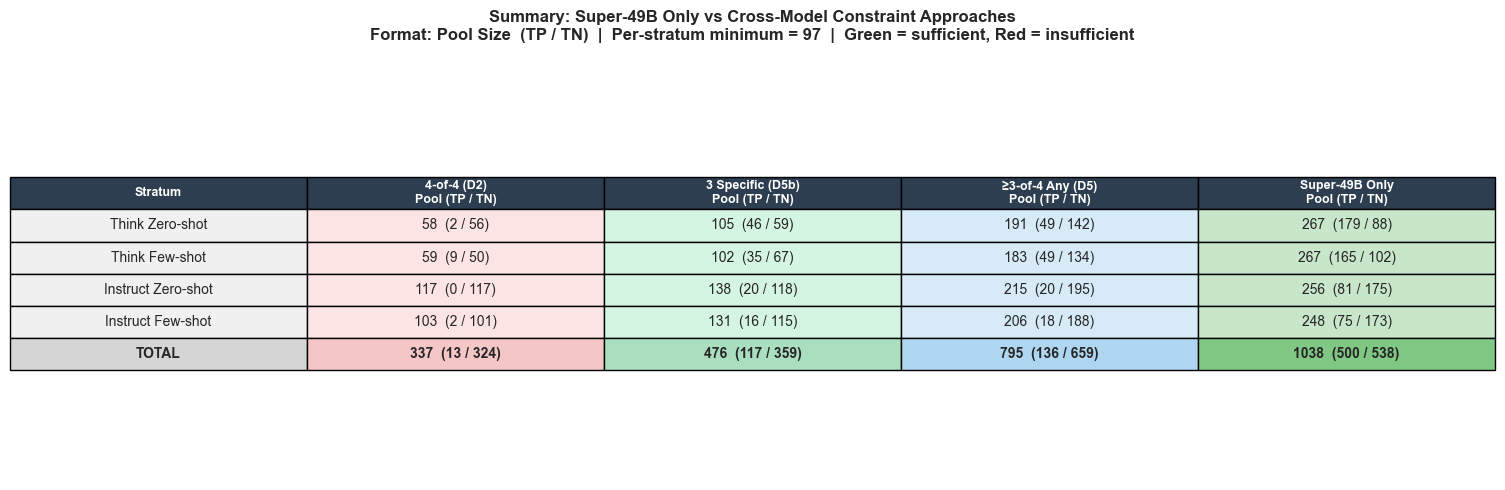

Saved: ../results/rq3_baseline/rq3_pool_super49b_summary_table.png


In [15]:
# 6d. Summary comparison table: Super-49B only vs cross-model approaches
fig, ax = plt.subplots(figsize=(15, 5))
ax.axis('off')

columns = ['Stratum',
           '4-of-4 (D2)\nPool (TP / TN)',
           '3 Specific (D5b)\nPool (TP / TN)',
           '\u22653-of-4 Any (D5)\nPool (TP / TN)',
           'Super-49B Only\nPool (TP / TN)']

strata_names = ['Think Zero-shot', 'Think Few-shot',
                'Instruct Zero-shot', 'Instruct Few-shot']

cell_data = []
cell_colors = []

for s, label in zip(STRATA_ORDER, strata_names):
    s49 = s49_stats[s]
    sufficient = s49['pool'] >= N_PER_STRATUM
    s49_color = '#c8e6c9' if sufficient else '#ffcdd2'
    row = [
        label,
        f"{d2_pool[s]}  ({d2_tp[s]} / {d2_tn[s]})",
        f"{d5b_pool[s]}  ({d5b_tp[s]} / {d5b_tn[s]})",
        f"{d5_pool[s]}  ({d5_tp[s]} / {d5_tn[s]})",
        f"{s49['pool']}  ({s49['tp']} / {s49['tn']})",
    ]
    cell_data.append(row)
    cell_colors.append(['#f0f0f0', '#fce4e4', '#d5f5e3', '#d6eaf8', s49_color])

# Totals row
s49_total = sum(s49_stats[s]['pool'] for s in STRATA_ORDER)
s49_tp_total = sum(s49_stats[s]['tp'] for s in STRATA_ORDER)
s49_tn_total = sum(s49_stats[s]['tn'] for s in STRATA_ORDER)

cell_data.append([
    'TOTAL',
    f"{d2_total}  ({d2_tp_total} / {d2_tn_total})",
    f"{d5b_total}  ({d5b_tp_total} / {d5b_tn_total})",
    f"{d5_total}  ({d5_tp_total} / {d5_tn_total})",
    f"{s49_total}  ({s49_tp_total} / {s49_tn_total})",
])
cell_colors.append(['#d5d5d5', '#f5c6c6', '#a9dfbf', '#aed6f1', '#81c784'])

table = ax.table(
    cellText=cell_data, colLabels=columns,
    cellColours=cell_colors, loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

# Style header row
for j in range(len(columns)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold', fontsize=9)

# Bold the totals row
for j in range(len(columns)):
    table[len(cell_data), j].set_text_props(fontweight='bold')

ax.set_title('Summary: Super-49B Only vs Cross-Model Constraint Approaches\n'
             f'Format: Pool Size  (TP / TN)  |  Per-stratum minimum = {N_PER_STRATUM}  |  '
             'Green = sufficient, Red = insufficient',
             fontsize=12, pad=20, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq3_pool_super49b_summary_table.png', bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR / "rq3_pool_super49b_summary_table.png"}')

### Key Observations — Best-Model (Super-49B) Approach

1. **All 4 strata individually meet the sampling threshold** (all ≥ 97 per stratum),
   unlike cross-model approaches where pool sizes drop significantly.

2. **TP/TN balance differs by mode**: Thinking strata are TP-heavy, instruct
   strata are TN-heavy. Stratified sampling within each stratum can balance this.

3. **Cross-stratum intersections are viable for paired comparisons**: The "Zero-shot only"
   (think ∩ inst) intersection exceeds the 97-sample threshold, enabling within-sample
   explanation comparison across modes.

4. **Justification**: Focusing on the best-performing model from RQ1 is defensible because
   RQ3 evaluates explanation quality, not model selection — using the strongest model
   ensures explanations are based on correct predictions, maximising the relevance
   of the human evaluation.

## 7. Second-Best Model Analysis: Qwen3-30B-A3B Only

Qwen3-30B-A3B is the second-best performing model for SA vulnerability detection
(best F1 = 0.544, thinking zero-shot). This section mirrors the Super-49B analysis
(Section 6) to evaluate whether Qwen3-30B-A3B's per-stratum pools are also
sufficient for stratified sampling, providing an alternative or complementary option.

In [16]:
# Build Qwen3-30B-A3B sub-matrix
q30_strata = [f'Qwen3-30B-A3B__{s}' for s in STRATA_ORDER]
q30_matrix = correct_matrix[q30_strata].copy()
q30_matrix.columns = STRATA_ORDER

# Per-stratum statistics
q30_stats = {}
for s in STRATA_ORDER:
    mask = q30_matrix[s]
    total = int(mask.sum())
    tp = int((mask & (gt == 1)).sum())
    tn = int((mask & (gt == 0)).sum())
    q30_stats[s] = {'pool': total, 'tp': tp, 'tn': tn}

# Cross-stratum intersections
q30_cross = {}
combos = [
    ('All 4 strata', STRATA_ORDER),
    ('Thinking only\n(zero + few)', ['think-zero', 'think-few']),
    ('Instruct only\n(zero + few)', ['inst-zero', 'inst-few']),
    ('Zero-shot only\n(think + inst)', ['think-zero', 'inst-zero']),
    ('Few-shot only\n(think + inst)', ['think-few', 'inst-few']),
    ('Think-zero +\nInst-few', ['think-zero', 'inst-few']),
    ('Think-few +\nInst-zero', ['think-few', 'inst-zero']),
]

for label, strata in combos:
    mask = q30_matrix[strata].all(axis=1)
    total = int(mask.sum())
    tp = int((mask & (gt == 1)).sum())
    tn = int((mask & (gt == 0)).sum())
    q30_cross[label] = {'pool': total, 'tp': tp, 'tn': tn}

# Union: correct in at least one stratum
any_correct_q30 = q30_matrix.any(axis=1)
q30_union = {
    'pool': int(any_correct_q30.sum()),
    'tp': int((any_correct_q30 & (gt == 1)).sum()),
    'tn': int((any_correct_q30 & (gt == 0)).sum()),
}

print('Qwen3-30B-A3B: Per-Stratum Pools')
print(f'{"Stratum":<15} {"Pool":>6} {"TP":>6} {"TN":>6} {"TP%":>7} {"Sufficient":>10}')
print('-' * 55)
for s in STRATA_ORDER:
    d = q30_stats[s]
    tp_pct = d['tp'] / d['pool'] * 100
    ok = 'YES' if d['pool'] >= N_PER_STRATUM else 'NO'
    print(f"{s:<15} {d['pool']:>6} {d['tp']:>6} {d['tn']:>6} {tp_pct:>6.1f}% {ok:>10}")

print(f'\nMinimum per stratum for 95% CI / 5% margin: {N_PER_STRATUM}')
print(f'Union (correct in >= 1 stratum): {q30_union["pool"]} (TP={q30_union["tp"]}, TN={q30_union["tn"]})')

Qwen3-30B-A3B: Per-Stratum Pools
Stratum           Pool     TP     TN     TP% Sufficient
-------------------------------------------------------
think-zero         268    125    143   46.6%        YES
think-few          255    107    148   42.0%        YES
inst-zero          264    110    154   41.7%        YES
inst-few           269    113    156   42.0%        YES

Minimum per stratum for 95% CI / 5% margin: 97
Union (correct in >= 1 stratum): 406 (TP=187, TN=219)


### 7a. Per-Stratum Pool Heatmap — Qwen3-30B-A3B Only

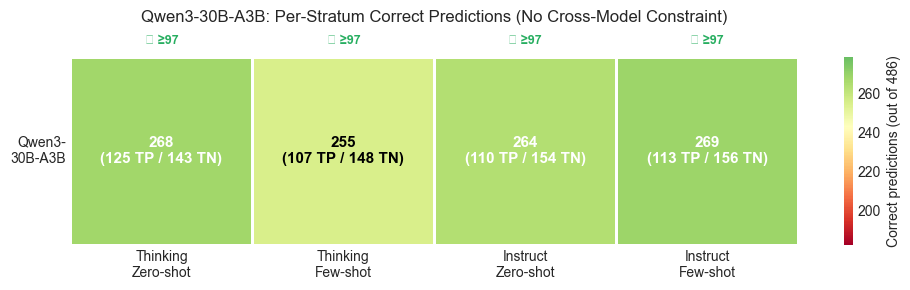

Saved: ../results/rq3_baseline/rq3_pool_qwen30b_heatmap.png


In [17]:
# 7a. Per-stratum heatmap for Qwen3-30B-A3B
fig, ax = plt.subplots(figsize=(10, 3))

pool_data = np.array([[q30_stats[s]['pool'] for s in STRATA_ORDER]])

sns.heatmap(
    pool_data, annot=False, cmap='RdYlGn',
    xticklabels=STRATA_LABELS,
    yticklabels=['Qwen3-\n30B-A3B'],
    ax=ax, linewidths=2, linecolor='white',
    vmin=vmin_d9b, vmax=vmax_d9b, center=half_n,
    cbar_kws={'label': f'Correct predictions (out of {n_samples})'}
)

# Custom annotations
for j, s in enumerate(STRATA_ORDER):
    d = q30_stats[s]
    color = 'white' if d['pool'] >= half_n * 1.08 else 'black'
    ax.text(j + 0.5, 0.5,
            f"{d['pool']}\n({d['tp']} TP / {d['tn']} TN)",
            ha='center', va='center', fontsize=11,
            fontweight='bold', color=color)

# Sufficiency markers
for j, s in enumerate(STRATA_ORDER):
    sufficient = q30_stats[s]['pool'] >= N_PER_STRATUM
    marker = '\u2714' if sufficient else '\u2718'
    color = '#27ae60' if sufficient else '#e74c3c'
    ax.text(j + 0.5, 1.05, f'{marker} \u2265{N_PER_STRATUM}',
            ha='center', va='bottom', fontsize=9, color=color,
            fontweight='bold', transform=ax.get_xaxis_transform())

ax.set_title('Qwen3-30B-A3B: Per-Stratum Correct Predictions (No Cross-Model Constraint)',
             fontsize=12, pad=25)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq3_pool_qwen30b_heatmap.png', bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR / "rq3_pool_qwen30b_heatmap.png"}')

### 7b. TP/TN Composition per Stratum — Qwen3-30B-A3B Only

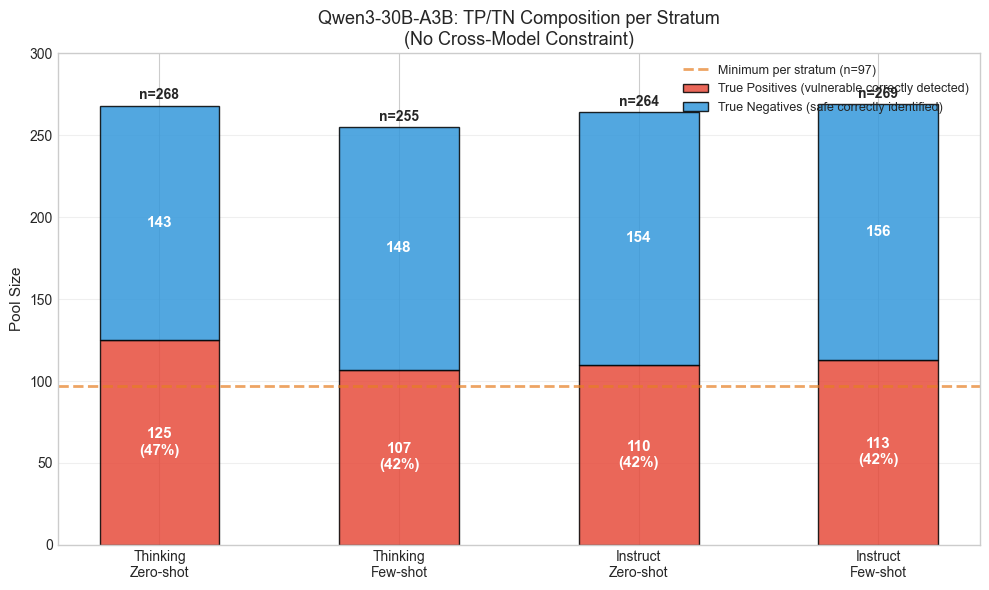

Saved: ../results/rq3_baseline/rq3_pool_qwen30b_tp_tn.png


In [18]:
# 7b. TP/TN composition stacked bars — Qwen3-30B-A3B
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(STRATA_ORDER))
width = 0.5

tp_vals = [q30_stats[s]['tp'] for s in STRATA_ORDER]
tn_vals = [q30_stats[s]['tn'] for s in STRATA_ORDER]

bars_tp = ax.bar(x, tp_vals, width,
                 label='True Positives (vulnerable correctly detected)',
                 color='#e74c3c', edgecolor='black', linewidth=1, alpha=0.85)
bars_tn = ax.bar(x, tn_vals, width, bottom=tp_vals,
                 label='True Negatives (safe correctly identified)',
                 color='#3498db', edgecolor='black', linewidth=1, alpha=0.85)

for i, s in enumerate(STRATA_ORDER):
    tp, tn = tp_vals[i], tn_vals[i]
    total = tp + tn
    tp_pct = tp / total * 100
    ax.text(i, tp / 2, f'{tp}\n({tp_pct:.0f}%)', ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')
    ax.text(i, tp + tn / 2, f'{tn}', ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')
    ax.text(i, total + 2, f'n={total}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.axhline(y=N_PER_STRATUM, color='#e67e22', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Minimum per stratum (n={N_PER_STRATUM})')

ax.set_xticks(x)
ax.set_xticklabels(STRATA_LABELS, fontsize=10)
ax.set_ylabel('Pool Size', fontsize=11)
ax.set_title('Qwen3-30B-A3B: TP/TN Composition per Stratum\n'
             '(No Cross-Model Constraint)',
             fontsize=13)
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 300)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq3_pool_qwen30b_tp_tn.png', bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR / "rq3_pool_qwen30b_tp_tn.png"}')

### 7c. Cross-Stratum Intersection Pools — Qwen3-30B-A3B Only

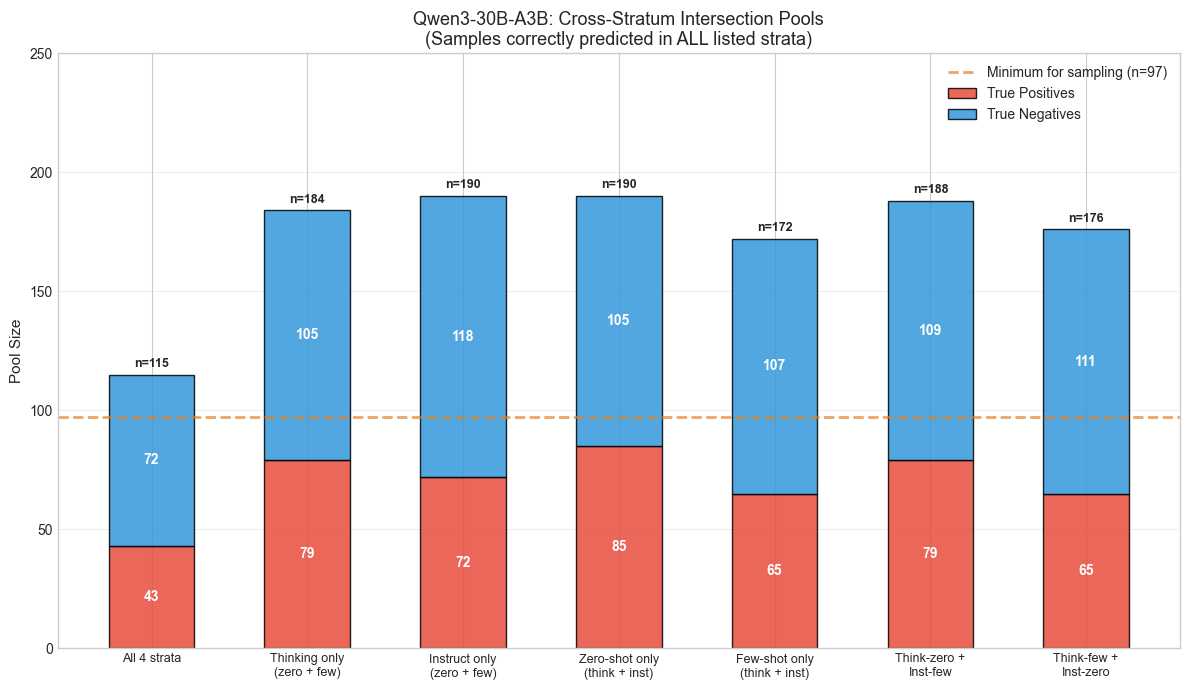

Saved: ../results/rq3_baseline/rq3_pool_qwen30b_intersections.png


In [19]:
# 7c. Cross-stratum intersection bar chart — Qwen3-30B-A3B
fig, ax = plt.subplots(figsize=(12, 7))

labels = list(q30_cross.keys())
pools = [q30_cross[k]['pool'] for k in labels]
tps = [q30_cross[k]['tp'] for k in labels]
tns = [q30_cross[k]['tn'] for k in labels]

x = np.arange(len(labels))
width = 0.55

bars_tp = ax.bar(x, tps, width, label='True Positives',
                 color='#e74c3c', edgecolor='black', linewidth=1, alpha=0.85)
bars_tn = ax.bar(x, tns, width, bottom=tps, label='True Negatives',
                 color='#3498db', edgecolor='black', linewidth=1, alpha=0.85)

for i in range(len(labels)):
    tp, tn = tps[i], tns[i]
    total = tp + tn
    if tp > 5:
        ax.text(i, tp / 2, f'{tp}', ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')
    ax.text(i, tp + tn / 2, f'{tn}', ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')
    ax.text(i, total + 2, f'n={total}', ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.axhline(y=N_PER_STRATUM, color='#e67e22', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Minimum for sampling (n={N_PER_STRATUM})')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9, ha='center')
ax.set_ylabel('Pool Size', fontsize=11)
ax.set_title('Qwen3-30B-A3B: Cross-Stratum Intersection Pools\n'
             '(Samples correctly predicted in ALL listed strata)',
             fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 250)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq3_pool_qwen30b_intersections.png', bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR / "rq3_pool_qwen30b_intersections.png"}')

### 7d. Summary Table — Qwen3-30B-A3B vs Super-49B vs Cross-Model

Direct comparison across all approaches: cross-model constraints, Super-49B only,
and Qwen3-30B-A3B only.

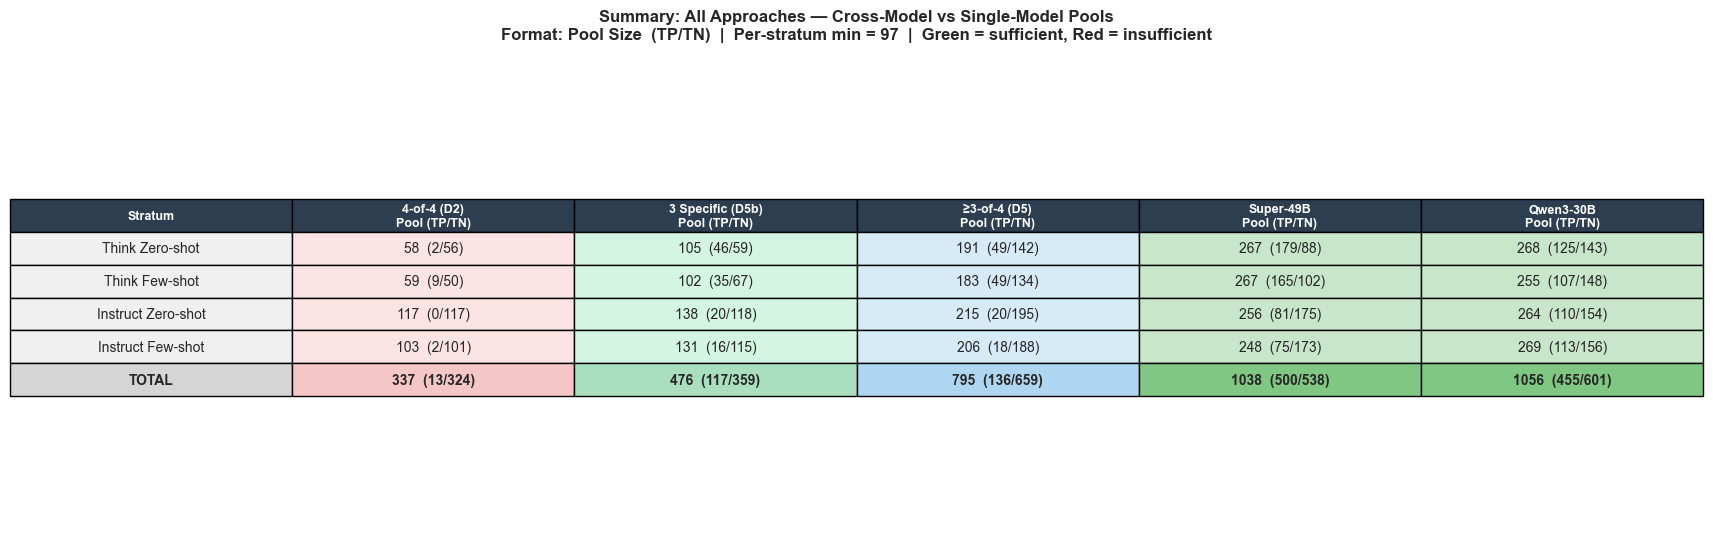

Saved: ../results/rq3_baseline/rq3_pool_all_approaches_summary.png


In [20]:
# 7d. Summary comparison table: all approaches including Qwen3-30B-A3B
fig, ax = plt.subplots(figsize=(17, 5.5))
ax.axis('off')

columns = ['Stratum',
           '4-of-4 (D2)\nPool (TP/TN)',
           '3 Specific (D5b)\nPool (TP/TN)',
           '\u22653-of-4 (D5)\nPool (TP/TN)',
           'Super-49B\nPool (TP/TN)',
           'Qwen3-30B\nPool (TP/TN)']

strata_names = ['Think Zero-shot', 'Think Few-shot',
                'Instruct Zero-shot', 'Instruct Few-shot']

cell_data = []
cell_colors = []

for s, label in zip(STRATA_ORDER, strata_names):
    s49 = s49_stats[s]
    q30 = q30_stats[s]
    s49_ok = s49['pool'] >= N_PER_STRATUM
    q30_ok = q30['pool'] >= N_PER_STRATUM
    row = [
        label,
        f"{d2_pool[s]}  ({d2_tp[s]}/{d2_tn[s]})",
        f"{d5b_pool[s]}  ({d5b_tp[s]}/{d5b_tn[s]})",
        f"{d5_pool[s]}  ({d5_tp[s]}/{d5_tn[s]})",
        f"{s49['pool']}  ({s49['tp']}/{s49['tn']})",
        f"{q30['pool']}  ({q30['tp']}/{q30['tn']})",
    ]
    cell_data.append(row)
    cell_colors.append([
        '#f0f0f0', '#fce4e4', '#d5f5e3', '#d6eaf8',
        '#c8e6c9' if s49_ok else '#ffcdd2',
        '#c8e6c9' if q30_ok else '#ffcdd2',
    ])

# Totals
q30_total = sum(q30_stats[s]['pool'] for s in STRATA_ORDER)
q30_tp_total = sum(q30_stats[s]['tp'] for s in STRATA_ORDER)
q30_tn_total = sum(q30_stats[s]['tn'] for s in STRATA_ORDER)

cell_data.append([
    'TOTAL',
    f"{d2_total}  ({d2_tp_total}/{d2_tn_total})",
    f"{d5b_total}  ({d5b_tp_total}/{d5b_tn_total})",
    f"{d5_total}  ({d5_tp_total}/{d5_tn_total})",
    f"{s49_total}  ({s49_tp_total}/{s49_tn_total})",
    f"{q30_total}  ({q30_tp_total}/{q30_tn_total})",
])
cell_colors.append(['#d5d5d5', '#f5c6c6', '#a9dfbf', '#aed6f1', '#81c784', '#81c784'])

table = ax.table(
    cellText=cell_data, colLabels=columns,
    cellColours=cell_colors, loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.15, 1.8)

for j in range(len(columns)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold', fontsize=9)

for j in range(len(columns)):
    table[len(cell_data), j].set_text_props(fontweight='bold')

ax.set_title('Summary: All Approaches — Cross-Model vs Single-Model Pools\n'
             f'Format: Pool Size  (TP/TN)  |  Per-stratum min = {N_PER_STRATUM}  |  '
             'Green = sufficient, Red = insufficient',
             fontsize=12, pad=20, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rq3_pool_all_approaches_summary.png', bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR / "rq3_pool_all_approaches_summary.png"}')

### Key Observations — Qwen3-30B-A3B vs Nemotron-Super-49B

1. **Qwen3-30B-A3B also meets the per-stratum threshold in all 4 strata**, confirming
   that a single-model approach is viable for either of the two best models.

2. **TP/TN balance is more even for Qwen3-30B-A3B** than for Super-49B, making it
   easier to draw balanced TP/TN samples without aggressive sub-stratification.

3. **Cross-stratum intersections are comparable**: Both models have pairwise intersections
   above the 97-sample threshold for "thinking only" and "zero-shot only" combinations.

4. **Model family diversity**: Using one model from each family (Nemotron + Qwen) would
   strengthen external validity. Alternatively, picking the single best model (Super-49B)
   maximises pool sizes and TP counts.

5. **Trade-off**: Super-49B has larger pools and more TP in thinking mode, but
   Qwen3-30B-A3B offers better TP/TN balance and cross-family representation.